In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from pycaret.anomaly import *
mpl.rcParams['figure.dpi'] = 150

df = pd.read_csv('../data/eu_regional_data.csv')

In [2]:
anomaly = setup(df, session_id = 8477)

,Description,Value
0,Session id,8477
1,Original data shape,"(237, 18)"
2,Transformed data shape,"(237, 283)"
3,Numeric features,15
4,Categorical features,3
5,Rows with missing values,40.5%
6,Preprocess,True
7,Imputation type,simple
8,Numeric imputation,mean
9,Categorical imputation,mode


In [27]:
model = create_model('lof', fraction = 0.05)
data_assigned = assign_model(model)

In [28]:
data_inliers = data_assigned.query('Anomaly == 0')
data_outliers = data_assigned.query('Anomaly == 1')
data_outliers

,region_name,Country,EU Region,GDP per Capita,GDP per Capita (PPS),Unemployment %,Employment in Hi-tech Sectors %,Life Expectancy,Doctors per 100K,Heart Disease Deaths per 100K,Cancer Deaths per 100K,Fatal Road Accidents per Million,Tertiary Educational Attainment %,Population Density,People at Risk of Poverty %,Regular Internet Users %,Land Covered by Buildings and Roads %,Land Covered by Crops %,Anomaly,Anomaly_Score
0,Région de Bruxelles-Capitale/ Brussels Hoofdst...,BE,Western Europe,82300.0,190.0,10.6,7.0,82.099998,518.679993,49.840000,211.029999,5.0,53.799999,7770.200195,38.900002,91.099998,37.000000,2.500000,1,2.465122
25,Hovedstaden,DK,Northern Europe,85000.0,170.0,5.2,11.1,81.900002,578.710022,46.990002,251.250000,17.0,55.099998,780.900024,17.900000,96.339996,16.299999,22.400000,1,2.483367
34,Oberbayern,DE,Western Europe,74700.0,174.0,2.3,9.3,82.400002,NaN,101.169998,207.050003,30.0,42.599998,274.399994,14.900000,NaN,7.700000,20.400000,1,1.942731
44,Hamburg,DE,Western Europe,84200.0,195.0,4.1,7.0,80.699997,NaN,87.610001,249.559998,15.0,40.000000,2594.600098,25.600000,NaN,29.799999,7.500000,1,2.523459
70,Southern,IE,Western Europe,104200.0,229.0,4.2,9.3,82.199997,NaN,124.550003,251.229996,37.0,50.400002,59.799999,17.700001,88.739998,5.100000,6.500000,1,3.512691
71,Eastern and Midland,IE,Western Europe,114200.0,251.0,4.5,11.5,83.099998,NaN,100.360001,243.039993,21.0,58.000000,182.899994,19.799999,92.570000,6.900000,11.000000,1,4.171396
101,Ciudad de Ceuta,ES,Southern Europe,22400.0,66.0,30.0,NaN,81.199997,601.570007,92.989998,204.970001,12.0,21.200001,4155.799805,41.799999,90.720001,NaN,NaN,1,1.725170
102,Ciudad de Melilla,ES,Southern Europe,20500.0,60.0,26.6,NaN,81.599998,NaN,91.059998,191.589996,0.0,32.799999,6124.200195,36.700001,96.629997,NaN,NaN,1,2.667554
160,Luxembourg,LU,Western Europe,123000.0,248.0,5.2,5.9,83.099998,NaN,50.250000,196.830002,39.0,51.900002,257.700012,NaN,93.129997,9.200000,20.200001,1,4.842078
161,Budapest,HU,Central and Eastern Europe,44700.0,164.0,2.3,12.2,78.800003,613.960022,313.209991,291.880005,26.0,56.200001,3291.399902,12.000000,95.400002,37.500000,7.200000,1,1.764473


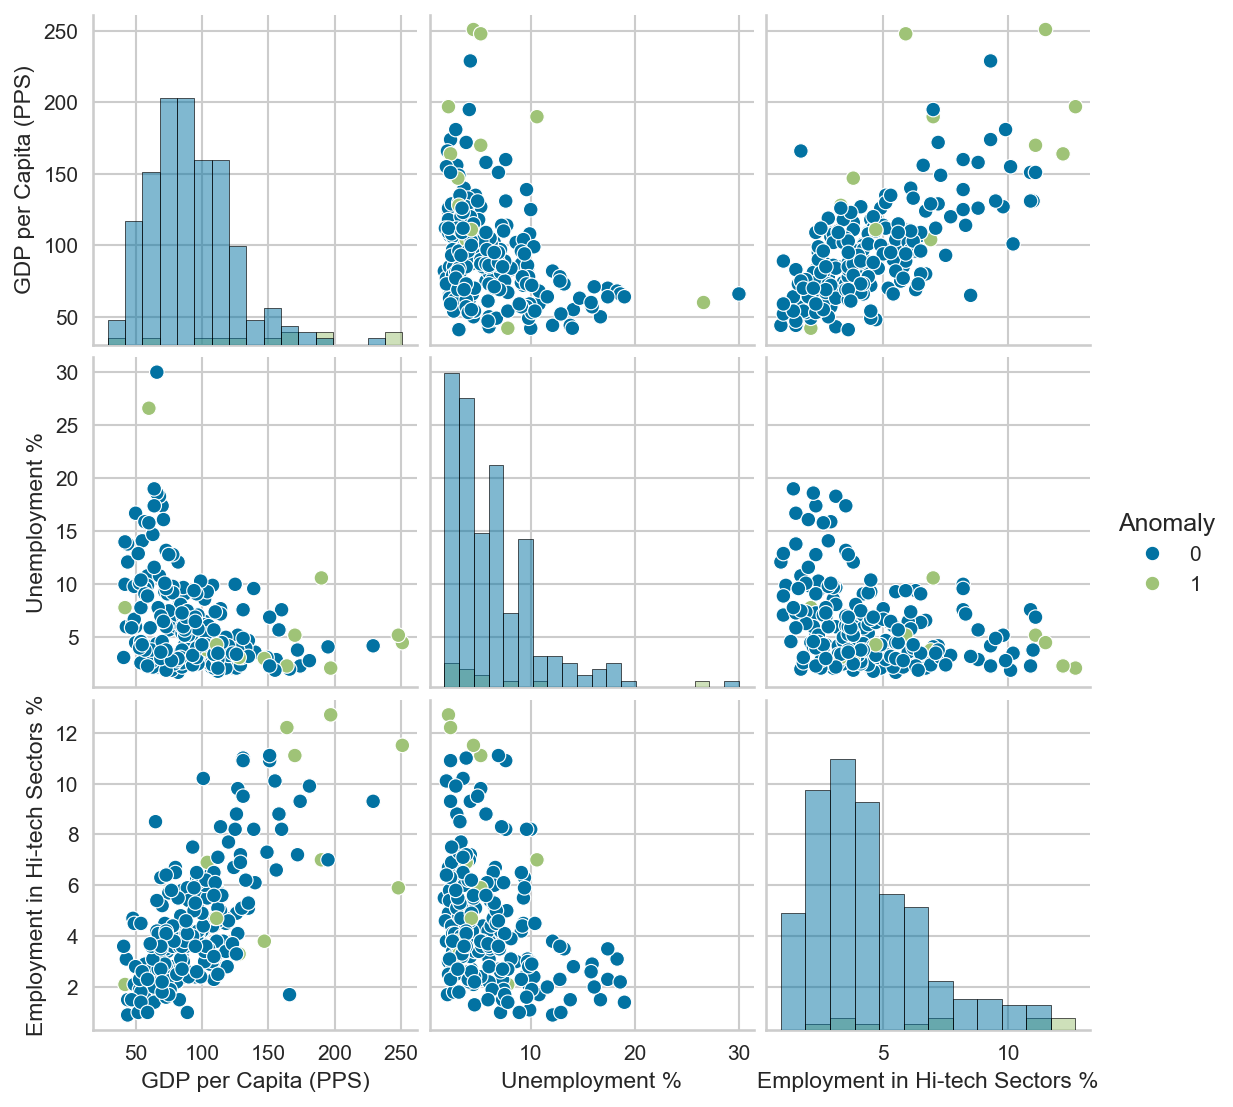

In [26]:
cols = ['GDP per Capita (PPS)', 'Unemployment %',
       'Employment in Hi-tech Sectors %']
sns.pairplot(data_assigned, vars=cols, hue='Anomaly', diag_kind = 'hist')
plt.show()

In [ ]:
data_assigned

,region_name,Country,EU Region,GDP per Capita,GDP per Capita (PPS),Unemployment %,Employment in Hi-tech Sectors %,Life Expectancy,Doctors per 100K,Heart Disease Deaths per 100K,Cancer Deaths per 100K,Fatal Road Accidents per Million,Tertiary Educational Attainment %,Population Density,People at Risk of Poverty %,Regular Internet Users %,Land Covered by Buildings and Roads %,Land Covered by Crops %,Anomaly,Anomaly_Score
0,Région de Bruxelles-Capitale/ Brussels Hoofdst...,BE,Western Europe,82300.0,190.0,10.6,7.0,82.099998,518.679993,49.840000,211.029999,5.0,53.799999,7770.200195,38.900002,91.099998,37.000000,2.500000,1,2.465122
1,Prov. Antwerpen,BE,Western Europe,60400.0,140.0,3.6,6.1,83.300003,294.480011,44.220001,204.500000,36.0,46.099998,686.299988,15.200000,90.809998,17.600000,23.500000,0,1.278552
2,Prov. Limburg (BE),BE,Western Europe,41300.0,96.0,3.2,4.1,83.199997,281.869995,42.189999,202.630005,36.0,42.200001,377.000000,11.700000,91.269997,12.600000,26.500000,0,0.992579
3,Prov. Oost-Vlaanderen,BE,Western Europe,48200.0,111.0,2.9,5.9,82.699997,315.010010,44.259998,216.720001,44.0,46.799999,528.299988,11.500000,91.559998,17.299999,26.400000,0,1.001749
4,Prov. Vlaams-Brabant,BE,Western Europe,55700.0,129.0,4.2,7.2,83.800003,289.130005,43.099998,200.589996,28.0,50.000000,564.299988,11.000000,94.139999,14.600000,30.299999,0,1.156328
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
232,Sydsverige,SE,Northern Europe,42700.0,94.0,9.4,5.9,82.900002,NaN,81.820000,212.740005,22.0,50.000000,113.400002,22.799999,92.709999,5.300000,26.400000,0,0.984715
233,Västsverige,SE,Northern Europe,50300.0,110.0,7.4,6.1,83.300003,NaN,84.500000,206.080002,24.0,48.500000,72.099998,18.000000,95.760002,4.000000,11.900000,0,0.978663
234,Norra Mellansverige,SE,Northern Europe,38700.0,85.0,7.3,2.7,82.699997,NaN,90.279999,206.919998,25.0,40.500000,13.500000,22.299999,96.099998,2.000000,1.400000,0,1.053603
235,Mellersta Norrland,SE,Northern Europe,43300.0,95.0,6.5,5.3,82.199997,NaN,102.889999,206.550003,35.0,41.000000,5.300000,17.700001,93.309998,1.100000,0.700000,0,0.980633


In [32]:
plot_model(model, 'tsne')